In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import polars as pl
import torch

import matplotlib.pyplot as plt
import seaborn as sns


import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import zscore
from tqdm import tqdm
from functools import partial


# home-grown
import utils as ut
import model as mod
import lazydata as lzdt

In [2]:
pd.options.display.max_columns = 60

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
df_mm, dict_colnames = ut.load_mm_dataset("med_seq")

In [5]:
df_mm.columns

Index(['sid', 'trial_id', 'left_intervention', 'PedPed', 'left_crossingsignal',
       'left_numberofcharacters', 'left_man', 'left_woman', 'left_pregnant',
       'left_stroller', 'left_oldman', 'left_oldwoman', 'left_boy',
       'left_girl', 'left_homeless', 'left_largewoman', 'left_largeman',
       'left_criminal', 'left_maleexecutive', 'left_femaleexecutive',
       'left_femaleathlete', 'left_maleathlete', 'left_femaledoctor',
       'left_maledoctor', 'left_dog', 'left_cat', 'right_picked',
       'right_intervention', 'right_crossingsignal',
       'right_numberofcharacters', 'right_man', 'right_woman',
       'right_pregnant', 'right_stroller', 'right_oldman', 'right_oldwoman',
       'right_boy', 'right_girl', 'right_homeless', 'right_largewoman',
       'right_largeman', 'right_criminal', 'right_maleexecutive',
       'right_femaleexecutive', 'right_femaleathlete', 'right_maleathlete',
       'right_femaledoctor', 'right_maledoctor', 'right_dog', 'right_cat',
       'sid_un

In [6]:
df_mm["any_old"] = ((df_mm["left_oldwoman"] > 0) | (df_mm["left_oldman"] > 0) | (df_mm["right_oldwoman"] > 0) | (df_mm["right_oldman"] > 0)).astype(int)

In [7]:
df_mm["old_diff"] = (np.abs((df_mm["left_oldwoman"] + df_mm["left_oldman"]) - (df_mm["right_oldwoman"] + df_mm["right_oldman"])) > 0).astype(int)

<Axes: >

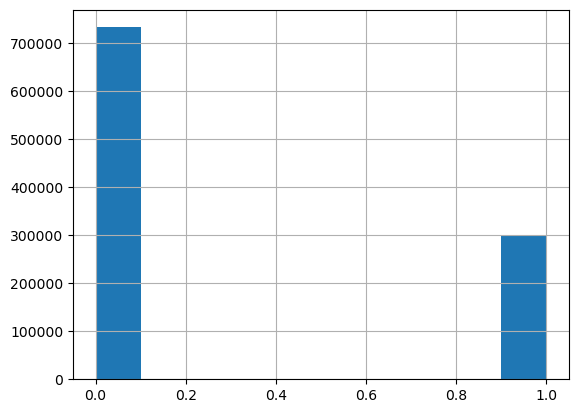

In [8]:
df_mm["old_diff"].hist()

<Axes: >

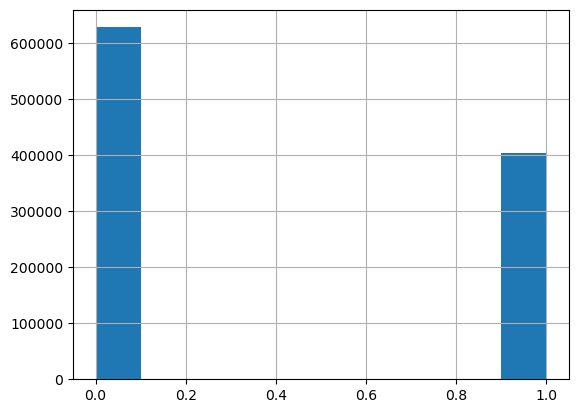

In [9]:
df_mm["any_old"].hist()

<Axes: >

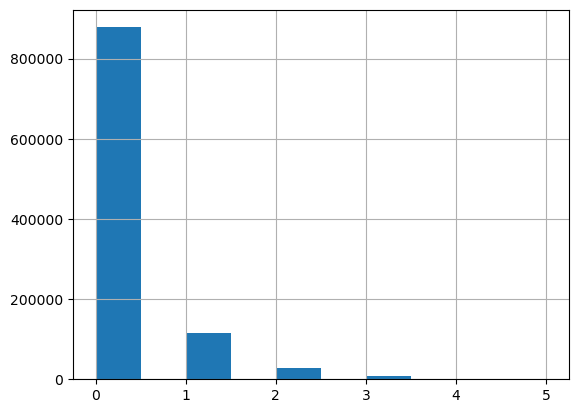

In [10]:
df_mm["left_oldwoman"].hist()

In [12]:
# balance dataset, because 77% Western, 16% southern, and only 7% Eastern
df_culture_sid = df_mm[["sid", "country_cluster"]].drop_duplicates().sort_values(["country_cluster", "sid"])
df_culture_sid["sid_by_cluster"] = df_culture_sid.groupby(["country_cluster"]).cumcount() + 1
# take the max from the eastern cluster, and throw out everything above that max from the other clusters
max_eastern = df_culture_sid.query("country_cluster == 'Eastern'")["sid_by_cluster"].max()
df_culture_sid = df_culture_sid.query(f"""sid_by_cluster <= {max_eastern}""")
df_mm = pd.merge(df_mm, df_culture_sid.drop(columns=["country_cluster", "sid_by_cluster"]), how="inner", on="sid")

In [13]:
max_eastern

1398

In [14]:
df_overview = df_mm[["sid", "country_cluster"]].drop_duplicates().value_counts("country_cluster").reset_index()
df_overview["n_cum"] = df_overview["count"].cumsum()
df_overview["prop"] = df_overview["count"] / df_overview["n_cum"].max()
df_overview

,country_cluster,count,n_cum,prop
0,Eastern,1398,1398,0.333333
1,Southern,1398,2796,0.333333
2,Western,1398,4194,0.333333


In [15]:
df_use = df_mm
dict_info = dict_colnames

In [16]:
df_use[dict_info["l_colnames_single_zscale"]] = df_use[dict_info["l_colnames_single_zscale"]].apply(zscore)

In [17]:
df_use = ut.shift_y(df_use)

drop button smashers

In [18]:
df_include = df_use.groupby("sid_unique")["right_picked"].agg(["mean", "count"]).reset_index().query("mean != 0 and mean != 1").sort_values("count")

In [19]:
df_use = pd.merge(df_include.drop(columns=["mean", "count"]), df_use, how="inner", on="sid_unique")

## Predict using sklearn Boosted Classifier

In [20]:
from sklearn.linear_model import LogisticRegression
from joblib import Parallel, delayed

In [21]:
df_cluster_assignment = df_use[["sid_unique", "country_cluster"]].drop_duplicates()

In [55]:
df_sample = df_cluster_assignment#.sample(100, random_state=908)

In [56]:
df_use["oldmen_rml"] = df_use["right_oldman"] - df_use["left_oldman"]
df_use["oldwomen_rml"] = df_use["right_oldwoman"] - df_use["left_oldwoman"]
df_use["boys_rml"] = df_use["right_boy"] - df_use["left_boy"]
df_use["girls_rml"] = df_use["right_girl"] - df_use["left_girl"]
df_use["men_rml"] = df_use["right_man"] - df_use["left_man"]
df_use["women_rml"] = df_use["right_woman"] - df_use["left_woman"]

In [57]:
X_train = df_use[["sid_unique", "oldmen_rml", "oldwomen_rml", "boys_rml", "girls_rml", "men_rml", "women_rml"]]
y_train = df_use[["sid_unique", "right_picked"]]

In [58]:
def fit_subject(current_id):
    m = LogisticRegression()
    X = X_train.query(f"""sid_unique == '{current_id}'""").drop(columns=["sid_unique"])
    y = np.ravel(y_train.query(f"""sid_unique == '{current_id}'""").drop(columns=["sid_unique"]))
    m.fit(X, y)
    return [
        current_id, np.round(m.coef_[0, 0], 2), np.round(m.coef_[0, 1], 2),
        np.round(m.coef_[0, 2], 2), np.round(m.coef_[0, 3], 2), 
        np.round(m.coef_[0, 4], 2), np.round(m.coef_[0, 5], 2)
    ]

In [59]:
ids_subset = df_sample["sid_unique"].to_list()

In [60]:
is_fit = True

In [61]:
if is_fit:
    t_start = os.times()[1]
    l_coefs = list(map(fit_subject, ids_subset))
    n_seconds_serial = os.times()[1] - t_start
    with open("data/variability-in-age-results.pickle", "wb") as f:
        pickle.dump(l_coefs, f)
else:
    with open("data/variability-in-age-results.pickle", "rb") as f:
        l_coefs = pickle.load(f)

In [62]:
print(f"""time serial: {n_seconds_serial}\n""")

time serial: 2.150000000000002



In [63]:
df_betas = pd.DataFrame(np.array(l_coefs))
df_betas.columns=["sid_unique", "oldmen_rml", "oldwomen_rml", "boys_rml", "girls_rml", "men_rml", "women_rml"]

In [64]:
df_betas = pd.merge(df_betas, df_cluster_assignment, how="left", on="sid_unique")

In [65]:
df_betas_long = df_betas.melt(id_vars=["sid_unique", "country_cluster"]).sort_values(["sid_unique", "variable"])
df_betas_long["value"] = np.round(df_betas_long["value"].astype(np.float16), 2)

In [66]:
def sterr(x):
    return np.std(x)/np.sqrt(len(x))

In [67]:
df_means = df_betas_long.groupby(["country_cluster", "variable"])["value"].agg(["count", "mean", sterr]).reset_index()

In [68]:
df_means.to_csv("data/mm-variability-age-culture-means.csv")

In [69]:
df_betas_long.to_csv("data/mm-variability-age-culture-indiv.csv")

In [70]:
df_means

,country_cluster,variable,count,mean,sterr
0,Eastern,boys_rml,1398,0.322588,0.010715
1,Eastern,girls_rml,1398,0.370410,0.011982
2,Eastern,men_rml,1398,0.117523,0.008867
3,Eastern,oldmen_rml,1398,0.053360,0.009638
4,Eastern,oldwomen_rml,1398,0.090357,0.009572
5,Eastern,women_rml,1398,0.160087,0.008985
6,Southern,boys_rml,1398,0.412634,0.010428
7,Southern,girls_rml,1398,0.501666,0.012367
8,Southern,men_rml,1398,0.103256,0.008828
9,Southern,oldmen_rml,1398,-0.007151,0.009729


In [71]:
df_betas_long.head()

,sid_unique,country_cluster,variable,value
9624,1000370545,Western,boys_rml,-0.219971
13818,1000370545,Western,girls_rml,-0.389893
18012,1000370545,Western,men_rml,-0.020004
1236,1000370545,Western,oldmen_rml,-0.219971
5430,1000370545,Western,oldwomen_rml,0.839844


/tmp/ipykernel_1329612/1314995476.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Boys", "Girls", "Men", "Old Men", "Old Women", "Women"], fontsize=12)
/tmp/ipykernel_1329612/1314995476.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)


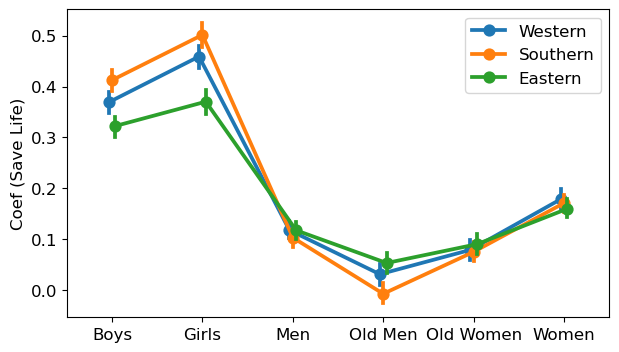

In [74]:
f, ax = plt.subplots(1, 1, figsize=(7, 4))

sns.pointplot(data=df_betas_long, x="variable", y="value", hue="country_cluster", errorbar=("ci", 95), dodge=True)
ax.set_xticklabels(["Boys", "Girls", "Men", "Old Men", "Old Women", "Women"], fontsize=12)
ax.set_ylabel("Coef (Save Life)", fontsize=12)
ax.set_xlabel("")
ax.legend(title="", fontsize=12)

ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)


plt.savefig("figures/variability-age-means.pdf")

In [75]:
np.corrcoef(df_betas["oldmen_rml"].astype(np.float16), df_betas["oldwomen_rml"].astype(np.float16))

array([[1.        , 0.12175322],
       [0.12175322, 1.        ]])

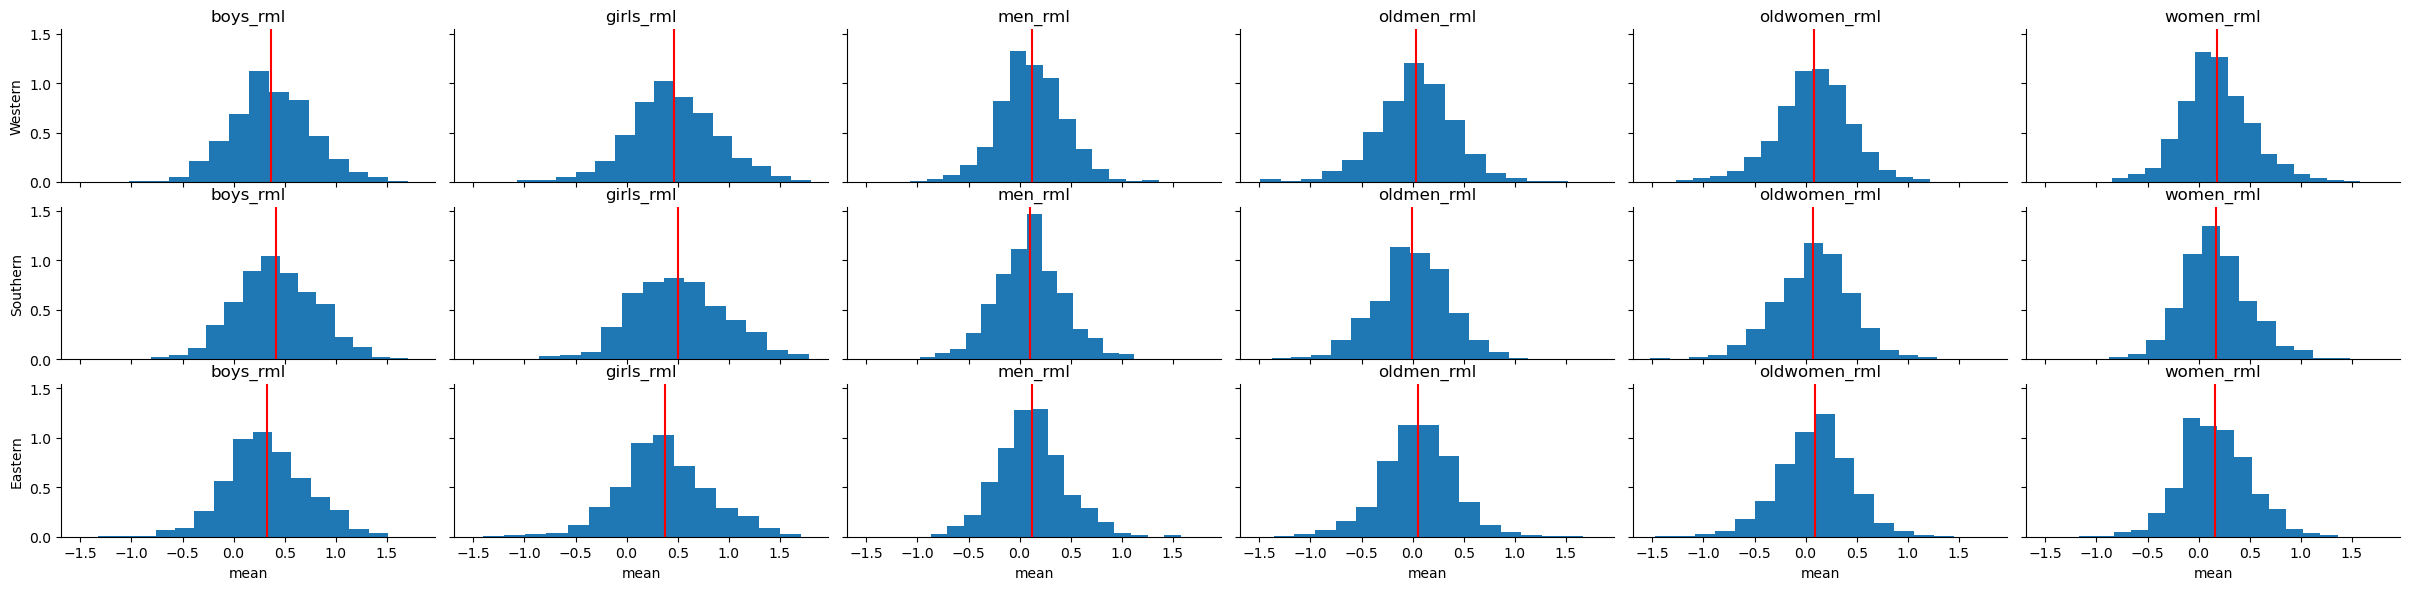

In [76]:
df_betas_long["source"] = "A"
df_means["source"] = "B"
df_means["sid_unique"] = None

df_all = pd.concat([df_betas_long, df_means], ignore_index=True)
 
def hist_func(data, x, bins, **kwargs):
    ax = kwargs.get("ax", plt.gca())
    subset = data[data["sid_unique"].notna()]
    ax.hist(subset[x], bins=bins, density=True)

def vline_func(data, x, **kwargs):
    ax = kwargs.get("ax", plt.gca())
    subset = data[data["sid_unique"].isna()]
    for val in subset[x]:
        ax.axvline(val, color="red")

g = sns.FacetGrid(df_all, col="variable", row="country_cluster", height=2, aspect=2, margin_titles=True)
g.set_titles(col_template="{col_name}", row_template="")

g.map_dataframe(hist_func, x="value", bins=15)
g.map_dataframe(vline_func, x="mean")

# After all your g.map_dataframe(...) calls
# After all your g.map_dataframe(...) calls
# After all g.map_dataframe(...) calls

for (row_val, col_val), ax in g.axes_dict.items():
    # Column titles
    ax.set_title(col_val)

    # Row titles on the left only
    if col_val == g.col_names[0]:
        ax.set_ylabel(row_val)
    else:
        ax.set_ylabel("")

plt.savefig("figures/variability-age-histogram.pdf")

In [77]:
df_betas_long["value_above_0"] = df_betas_long["value"] > 0
df_betas_long["value_below_0"] = df_betas_long["value"] <= 0

In [78]:
df_betas_long.groupby(["variable", "country_cluster"])[["value_above_0", "value_below_0"]].agg(["count", "sum", "mean"]).reset_index()

variable country_cluster value_above_0                 value_below_0  \
                                         count   sum      mean         count   
0       boys_rml         Eastern          1398  1125  0.804721          1398   
1       boys_rml        Southern          1398  1194  0.854077          1398   
2       boys_rml         Western          1398  1159  0.829041          1398   
3      girls_rml         Eastern          1398  1145  0.819027          1398   
4      girls_rml        Southern          1398  1214  0.868383          1398   
5      girls_rml         Western          1398  1221  0.873391          1398   
6        men_rml         Eastern          1398   888  0.635193          1398   
7        men_rml        Southern          1398   886  0.633763          1398   
8        men_rml         Western          1398   895  0.640200          1398   
9     oldmen_rml         Eastern          1398   779  0.557225          1398   
10    oldmen_rml        Southern          1398   697  0.498569          1398   
11    oldmen_rml         Western          1398   764  0.546495          1398   
12  oldwomen_rml         Eastern          1398   846  0.605150          1398   
13  oldwomen_rml        Southern          1398   847  0.605866          1398   
14  oldwomen_rml         Western          1398   832  0.595136          1398   
15     women_rml         Eastern          1398   928  0.663805          1398   
16     women_rml        Southern          1398   951  0.680258          1398   
17     women_rml         Western          1398   987  0.706009          1398   

                   
    sum      mean  
0   273  0.195279  
1   204  0.145923  
2   239  0.170959  
3   253  0.180973  
4   184  0.131617  
5   177  0.126609  
6   510  0.364807  
7   512  0.366237  
8   503  0.359800  
9   619  0.442775  
10  701  0.501431  
11  634  0.453505  
12  552  0.394850  
13  551  0.394134  
14  566  0.404864  
15  470  0.336195  
16  447  0.319742  
17  411  0.293991